In [ ]:
%pip install -e .
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from services.parser.pdf_reader_n_clearner import pdf_reader
from agents.Job_ranker import start_career_optimization
from services.scraper.Job_scraper import fetch_jobs
from agents.Resume_extraction_agent import Resume_extaction
from agents.resume_rewrite_agent import resume_rewrite
from agents.suggested_Job_formating import suggested_Job_formating
from agents.human_rewritter_agent import human_rewritter_agent
from core.Nodes.select_job import select_job_details

from core.Nodes.Conditions import ingestion_condition, skill_extraction_condition, job_search_condition, critic_resume_rewrite_condition
from core.Nodes.GraphState import GraphState
from langgraph.checkpoint.memory import MemorySaver

from langgraph.graph import StateGraph,START,END

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///C:/Users/USER/Documents/Projects/Main%20projects/AI%20Career%20Optimization%20System/core/Nodes
Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/USER/Documents/Projects/Main%20projects/AI%20Career%20Optimization%20System/core/Nodes does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


ImportError: cannot import name 'job_ranker' from 'agents.Job_ranker' (c:\Users\USER\Documents\Projects\Main projects\AI Career Optimization System\agents\Job_ranker.py)

In [ ]:
def nodes():
    graph = StateGraph(GraphState)

    # 1. ADD NODES
    graph.add_node('pdf_reader', pdf_reader)
    graph.add_node('Resume_extaction', Resume_extaction)
    graph.add_node('fetch_jobs', fetch_jobs)
    graph.add_node('start_career_optimization', start_career_optimization)
    # NEW: This node prunes the 60 jobs down to 1
    graph.add_node('select_job_details', select_job_details) 
    
    graph.add_node('suggested_Job_formating', suggested_Job_formating)
    graph.add_node('resume_rewrite', resume_rewrite)
    graph.add_node('human_rewritter_agent', human_rewritter_agent)

    # 2. DEFINE EDGES
    graph.add_edge(START, 'pdf_reader')
    graph.add_edge('pdf_reader', 'Resume_extaction')

    # Extraction -> Formatting
    graph.add_conditional_edges('Resume_extaction', ingestion_condition, {
        "passed": 'suggested_Job_formating',
        "retry": 'Resume_extaction',
        "failed": END
    })

    # Formatting -> Scraper
    graph.add_conditional_edges('suggested_Job_formating', skill_extraction_condition, {
        "passed": 'fetch_jobs', 
        "retry": 'suggested_Job_formating',
        "failed": END
    })

    # Scraper -> Selection (NEW FLOW)
    # Instead of going straight to rewrite, we go to our selection node
    graph.add_edge('fetch_jobs', 'start_career_optimization')
    graph.add_edge('start_career_optimization', 'select_job_details')

    # Selection -> Rewrite (The Pruned Path)
    graph.add_conditional_edges('select_job_details', critic_resume_rewrite_condition, {
        "Procced": 'resume_rewrite',
        "retry": 'fetch_jobs' 
    })

    graph.add_edge('resume_rewrite', 'human_rewritter_agent')
    graph.add_edge('human_rewritter_agent', END)

    # 3. COMPILE WITH INTERRUPT
    memory = MemorySaver()
    # We interrupt BEFORE select_job_details so the user can provide the ID
    app = graph.compile(
        checkpointer=memory,
        interrupt_before=["select_job_details"]
    )

    return app

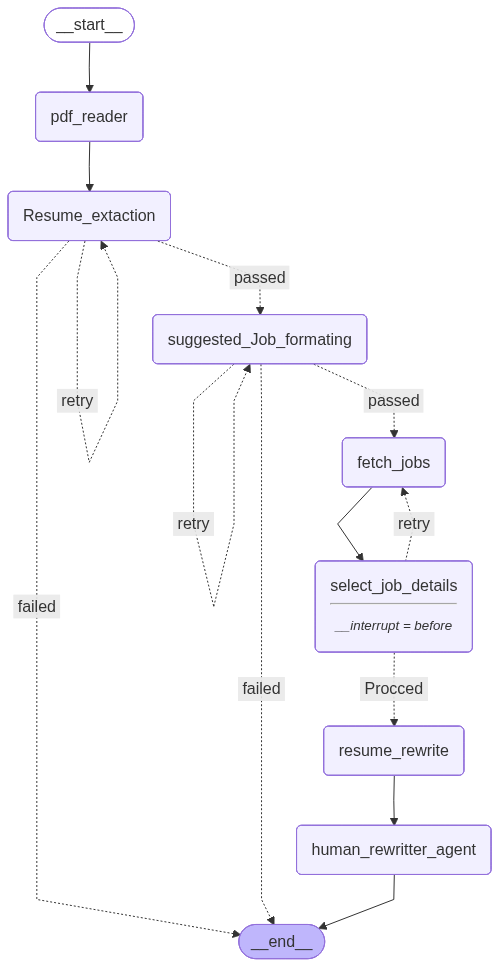

In [19]:
app = nodes()
# Visualize the graph
from IPython.display import Image, display

# Get the graph visualization
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))